# 1D Quantum Harmonic Oscillator: Finite-Difference Hamiltonian

This notebook calculates the approximate second derivative of the quantum harmonic oscillator and constructs a hamiltonian matrix:
Everything here is kept in **one spatial dimension**,
We use dimensionless units, $\hbar = m = \omega = 1$, so the Hamiltonian is
$$
H = -\frac{1}{2}\frac{d^2}{dx^2} + \frac{1}{2}x^2 ,
$$
and the known analytic energies are $E_n = n + \tfrac{1}{2}$. These are the
same conventions used throughout the project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh_tridiagonal
from scipy.special import eval_hermite, gammaln
pd.set_option("display.precision", 10)

## Shared grid and parameter definitions

- Physical units: dimensionless, $\hbar = m = \omega = 1$
- Spatial interval: $x \in [-L, L]$ with $L = 8$
- Number of grid points: $N = 1000$, including the two boundary points
- Boundary condition: Dirichlet, $\psi(\pm L) = 0$
- Requested eigenstates: the lowest 6

In [2]:
# Dimensionless units
hbar = 1.0
mass = 1.0
omega = 1.0
# Shared numerical-box parameters
L = 8.0
N = 1000
num_states = 6
# Full grid, including the two boundary points
x_full = np.linspace(-L, L, N)
dx = x_full[1] - x_full[0]
# Dirichlet boundary conditions fix psi(-L) = psi(L) = 0, so only the interior points are unknowns in the eigenvalue problem.
x = x_full[1:-1]
M = x.size
print(f"Domain: [{-L}, {L}]")
print(f"Total grid points N: {N}")
print(f"Interior unknowns M: {M}")
print(f"Grid spacing dx: {dx:.6f}")

Domain: [-8.0, 8.0]
Total grid points N: 1000
Interior unknowns M: 998
Grid spacing dx: 0.016016


## Finite-difference second derivative

For an interior grid point $x_i$, the centered, second-order finite
difference approximation to the second derivative is
$$
\left.\frac{d^2\psi}{dx^2}\right|_{x_i} \approx
\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\Delta x^2}.
$$

Applied at every interior point, this turns the derivative into a
tridiagonal matrix with $-2$ on the main diagonal and $1$ on the first
off-diagonals (before dividing by $\Delta x^2$).

To make the pattern easy to check by eye, we first build this matrix on a
tiny 6-point grid before using it at full resolution.

In [3]:
# Small demonstration grid
M_demo = 6
lower_demo = np.ones(M_demo - 1)
main_demo = -2.0 * np.ones(M_demo)
upper_demo = np.ones(M_demo - 1)
D2_demo = diags(
    [lower_demo, main_demo, upper_demo], [-1, 0, 1], shape=(M_demo, M_demo)
).toarray()
print("Unscaled second-derivative pattern (before dividing by dx^2):")
print(D2_demo)
assert D2_demo.shape == (M_demo, M_demo), "unexpected shape"
assert np.allclose(D2_demo, D2_demo.T), "pattern is not symmetric"
assert np.allclose(np.diag(D2_demo), -2.0), "main diagonal should be -2"
print("\nShape, symmetry, and diagonal value all check out.")

Unscaled second-derivative pattern (before dividing by dx^2):
[[-2.  1.  0.  0.  0.  0.]
 [ 1. -2.  1.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.  0.]
 [ 0.  0.  1. -2.  1.  0.]
 [ 0.  0.  0.  1. -2.  1.]
 [ 0.  0.  0.  0.  1. -2.]]

Shape, symmetry, and diagonal value all check out.


In [4]:
# Full-resolution second-derivative matrix, stored as sparse CSR
lower = np.ones(M - 1)
main = -2.0 * np.ones(M)
upper = np.ones(M - 1)
D2 = diags(
    diagonals=[lower, main, upper],
    offsets=[-1, 0, 1],
    shape=(M, M),
    format="csr",
) / dx**2
print(f"D2 shape: {D2.shape}")
print(f"D2 symmetric to numerical precision: {abs(D2 - D2.T).max() < 1e-10}")
print(f"D2 stored nonzeros: {D2.nnz} (expected {3*M - 2})")

D2 shape: (998, 998)
D2 symmetric to numerical precision: True
D2 stored nonzeros: 2992 (expected 2992)


## Hamiltonian matrix

Adding the harmonic potential on the main diagonal completes the discrete Hamiltonian
$$
H = -\frac{\hbar^2}{2m}D_2 + \operatorname{diag}\!\left(\tfrac{1}{2}m\omega^2 x_i^2\right),
$$
which is real, symmetric, and tridiagonal on the $M$ interior points.

In [5]:
V = 0.5 * mass * omega**2 * x**2
H = -0.5 * (hbar**2 / mass) * D2 + diags(V, offsets=0, format="csr")
print(f"H shape: {H.shape}")
print(f"H stored nonzeros: {H.nnz} (expected {3*M - 2})")
print(f"H symmetric to numerical precision: {abs(H - H.T).max() < 1e-10}")

H shape: (998, 998)
H stored nonzeros: 2992 (expected 2992)
H symmetric to numerical precision: True


## Choice of numerical eigensolver

The eigenvalue problem is solved with **`scipy.sparse.linalg.eigsh`**, called with
`k = num_states` and `which="SA"`.

Reasons for this choice:

- $H$ is real and symmetric, which is exactly the class `eigsh` (Lanczos / ARPACK)
  is written for, so the returned eigenvalues are real and the eigenvectors are
  orthogonal by construction.
- Only the lowest few states are needed. `eigsh` returns the requested $k$
  eigenpairs instead of the full $M \times M$ spectrum, and `which="SA"` selects the
  algebraically smallest eigenvalues, which are the lowest energies.
- $H$ is stored sparsely, so the solver only touches the $3M - 2$ nonzero entries
  rather than the $M^2$ entries a dense solver such as `numpy.linalg.eigh` would
  need. This keeps the method usable at the finer grids used in the convergence
  tests.

As a check on the solver rather than on the discretization, the same eigenvalues are
recomputed with the direct tridiagonal solver `scipy.linalg.eigh_tridiagonal`, which
uses a completely different algorithm.

In [6]:
energies_num, states = eigsh(H, k=num_states, which="SA")
order = np.argsort(energies_num)
energies_num = energies_num[order]
states = states[:, order]
for j in range(num_states):
    states[:, j] /= np.sqrt(np.trapezoid(np.abs(states[:, j])**2, x))
for j in range(num_states):
    print(f"E_{j} = {energies_num[j]:.10f}")

E_0 = 0.4999919838
E_1 = 1.4999599187
E_2 = 2.4998957872
E_3 = 3.4997995877
E_4 = 4.4996713187
E_5 = 5.4995109787


In [7]:
diag_ref = hbar**2 / (mass * dx**2) + V
offdiag_ref = -0.5 * (hbar**2 / mass) * np.ones(M - 1) / dx**2
energies_ref = eigh_tridiagonal(
    diag_ref, offdiag_ref, eigvals_only=True, select="i", select_range=(0, num_states - 1)
)
solver_difference = np.abs(energies_num - energies_ref).max()
print(f"Largest eigsh vs eigh_tridiagonal difference: {solver_difference:.3e}")
assert solver_difference < 1e-9, "the two solvers disagree"
overlap = states.T @ states * dx
print(f"Maximum normalization error: {np.max(np.abs(np.diag(overlap) - 1.0)):.3e}")
print(f"Maximum orthogonality error: {np.max(np.abs(overlap - np.eye(num_states))):.3e}")

Largest eigsh vs eigh_tridiagonal difference: 5.254e-13
Maximum normalization error: 2.276e-14
Maximum orthogonality error: 2.276e-14


## Comparison with the analytic energies

For the exact harmonic oscillator in these units the energies are
$$
E_n = n + \tfrac{1}{2}, \qquad n = 0, 1, 2, \dots
$$
The table below lists the lowest six numerical levels next to those values, with the
absolute difference $|E_n^{\text{num}} - E_n|$ and the relative difference in percent.

In [8]:
n = np.arange(num_states)
energies_exact = n + 0.5
absolute_difference = np.abs(energies_num - energies_exact)
relative_difference_percent = 100.0 * absolute_difference / energies_exact

comparison = pd.DataFrame({
    "n": n,
    "Numerical energy": energies_num,
    "Analytic energy": energies_exact,
    "Absolute difference": absolute_difference,
    "Relative difference (%)": relative_difference_percent,
})
comparison

,n,Numerical energy,Analytic energy,Absolute difference,Relative difference (%)
0,0,0.4999919838,0.5,0.0000080162,0.0016032305
1,1,1.4999599187,1.5,0.0000400813,0.0026720851
2,2,2.4998957872,2.5,0.0001042128,0.0041685124
3,3,3.4997995877,3.5,0.0002004123,0.0057260656
4,4,4.4996713187,4.5,0.0003286813,0.0073040284
5,5,5.4995109787,5.5,0.0004890213,0.0088912963


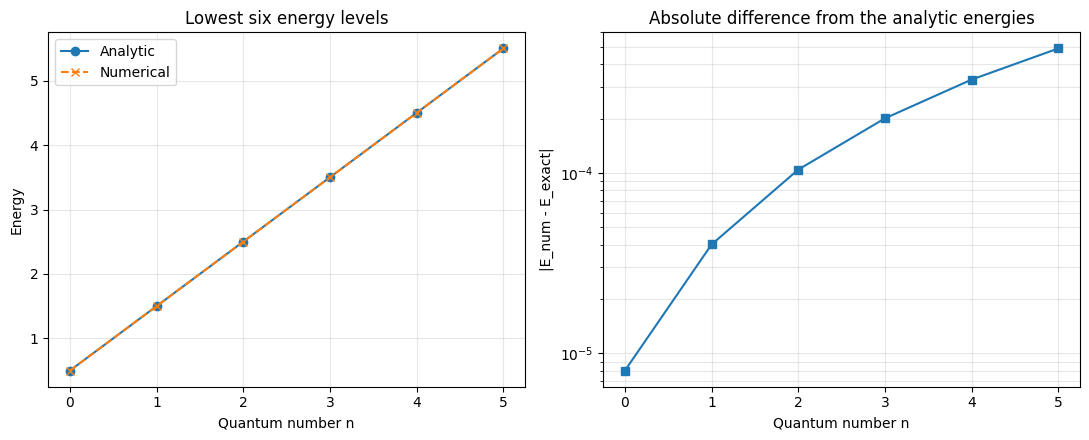

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(n, energies_exact, "o-", label="Analytic")
axes[0].plot(n, energies_num, "x--", label="Numerical")
axes[0].set_xlabel("Quantum number n")
axes[0].set_ylabel("Energy")
axes[0].set_title("Lowest six energy levels")
axes[0].set_xticks(n)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].semilogy(n, absolute_difference, "s-")
axes[1].set_xlabel("Quantum number n")
axes[1].set_ylabel("|E_num - E_exact|")
axes[1].set_title("Absolute difference from the analytic energies")
axes[1].set_xticks(n)
axes[1].grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()

## Result

On this grid the six lowest numerical levels reproduce $E_n = n + \tfrac{1}{2}$ to
better than $5 \times 10^{-4}$ in absolute terms and better than $0.01\%$ relative,
and the two independent solvers agree with each other to roughly $10^{-13}$. The
remaining difference is therefore discretization error, not solver error.

Two features of that error are visible in the table:

- Every numerical level sits slightly *below* the analytic value, because the
  centered finite difference underestimates the curvature of the wavefunction and so
  underestimates the kinetic energy.
- The difference grows with $n$: higher states oscillate faster and are wider, so
  they are resolved less well by a fixed grid spacing and feel the finite box more.

The error term of the centered second difference is $O(\Delta x^2)$, so both effects
should shrink by a factor of about four each time the grid spacing is halved. That
scaling, and the dependence on the box size $L$, are tested in the convergence
section of the project.